#### section 2

##### 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from forces import calculateForceVectors

##### 2

In [2]:
from leapfrog import updateParticles

In [3]:
# test scenario

a = [1, 0, 0]
b = [-1, 0, 0]
ab = np.array([a, b])
c = np.zeros((2, 3))
m = np.array([1000, 1000])

p, v = updateParticles(m, ab, c, 10000)
print(p)

# expected result, the particles accelerate towards each other along the x axis

[[ 0.16625  0.       0.     ]
 [-0.16625  0.       0.     ]]


##### 3

In [4]:
def calculateTrajectories(masses, pNaught, vNaught, t, dt):
    '''
    Evolves a system of N particles over time in even increments 
    based on their gravitational force and initial conditions.

    Parameters
    ----------
    masses : np.ndarray
        1-D array containing masses for all particles, in kg
        Has length N, where N is the number of particles.
    positions : np.ndarray
        2-D containing (x, y, z) positions for all particles.
        Has shape (N, 3) where N is the number of particles.
    velocities : np.ndarray
        2-D containing (x, y, z) velocities for all particles.
        Has shape (N, 3) where N is the number of particles.
    total time : float
        Total time over which to evolve the system, in seconds
    dt : float
        Incremental steps of time in in which information about
        the particle is saved.

    Returns
    -------
    3 np.ndarrays of times (1-D) and the corresponding (x, y, z) positions
    and velocities at each (2-D).

    Example
    -------
    Evolve a system of 2 particles w/ masses 1, 2 at rest w/ positions 
    (0, 0, 1) and (0, 0, 0) over 30 seconds every 2 seconds.

    calculateTrajectories(np.array([1, 2]), np.array([[0, 0, 1],[0, 0, 0]]), np.zeros(2, 3), 30, 2)
    '''
    
    times = np.arange(0, t+(dt/2), dt)  # np.arange non inclusive
    
    p = [pNaught] # list w initial positions
    v = [vNaught] # list w initial velocities
    for i in range(len(times) - 1):
        ps, vs = updateParticles(masses, p[i], v[i], dt)
        p.append(ps) # add updated positions
        v.append(vs) # add updated velocities

    positions = np.array(p) # convert to numpy arrays
    velocities = np.array(v)
    
    return positions, velocities, times

#### section 3

##### 4

In [5]:
# test
secInDay = 24 * 60 * 60
mInAU = 1.496e11

m = np.array([1.989e30, 5.972e24])
p = np.array([[-3e-6, 0, 0], [0.9997, 0, 0]]) * mInAU
v = np.array([[0, -8.94e-2, 0], [0, 2.98e4, 0]])
t = 1000 * secInDay  # seconds
dt = secInDay * 0.1


ptest, vtest, ttest = calculateTrajectories(m, p, v, t, dt)
# back to AU, days
ttest = ttest/(24*60*60)
ptest = ptest/1.496e11


print(ptest.shape)  # times * # of particles * (x, y, z)
print(vtest.shape)  # times * # of particles * v(x, y, z)
print(ttest.shape)  # times
print(type(ttest))

(10001, 2, 3)
(10001, 2, 3)
(10001,)
<class 'numpy.ndarray'>


##### 5

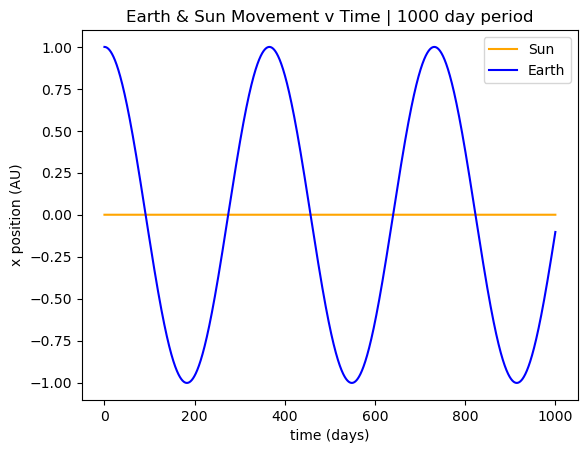

In [6]:
plt.plot(ttest, ptest[:, 0, 0], c='orange', label='Sun')
plt.plot(ttest, ptest[:, 1, 0], c='blue', label='Earth')
plt.xlabel('time (days)')
plt.ylabel('x position (AU)')
plt.title('Earth & Sun Movement v Time | 1000 day period')
plt.legend();

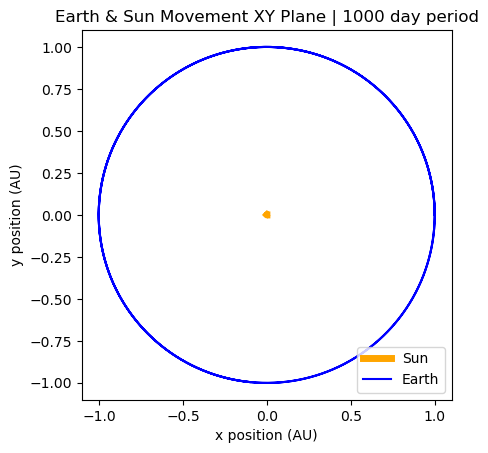

In [7]:
plt.plot(ptest[:, 0, 0], ptest[:, 0, 1], c='orange', label='Sun', lw=5)
plt.plot(ptest[:, 1, 0], ptest[:, 1, 1] , c='blue', label='Earth')
plt.axis('square')
plt.xlabel('x position (AU)')
plt.ylabel('y position (AU)')
plt.title('Earth & Sun Movement XY Plane | 1000 day period')
plt.legend();

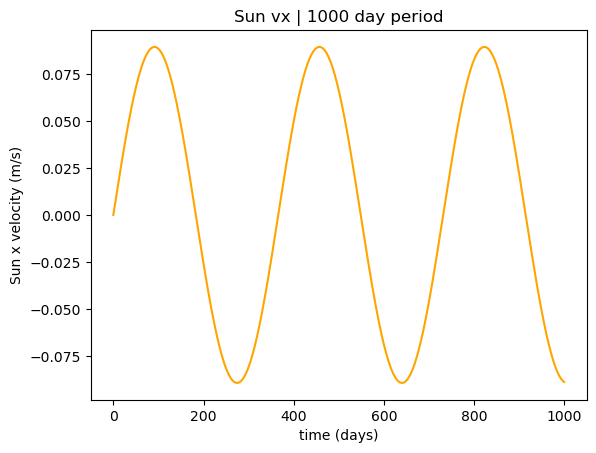

In [8]:
plt.plot(ttest, vtest[:, 0, 0], c='orange')
plt.xlabel('time (days)')
plt.ylabel('Sun x velocity (m/s)')
plt.title('Sun vx | 1000 day period');

##### 6

In [9]:
# decreasing initial velocities by factor of 2
# test

ptest2, vtest2, ttest2 = calculateTrajectories(m, p, v/2, t, dt)
# back to AU, days
ttest2 = ttest2/secInDay
ptest2 = ptest2/mInAU

print(ptest.shape)
print(vtest.shape)
print(ttest.shape)
print(type(ttest))

(10001, 2, 3)
(10001, 2, 3)
(10001,)
<class 'numpy.ndarray'>


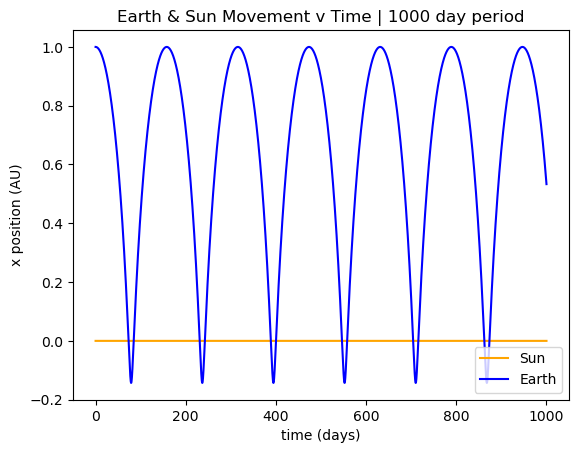

In [10]:
plt.plot(ttest2, ptest2[:, 0, 0], c='orange', label='Sun')
plt.plot(ttest2, ptest2[:, 1, 0], c='blue', label='Earth')
plt.xlabel('time (days)')
plt.ylabel('x position (AU)')
plt.title('Earth & Sun Movement v Time | 1000 day period')
plt.legend();

# more drastic variation in velocity

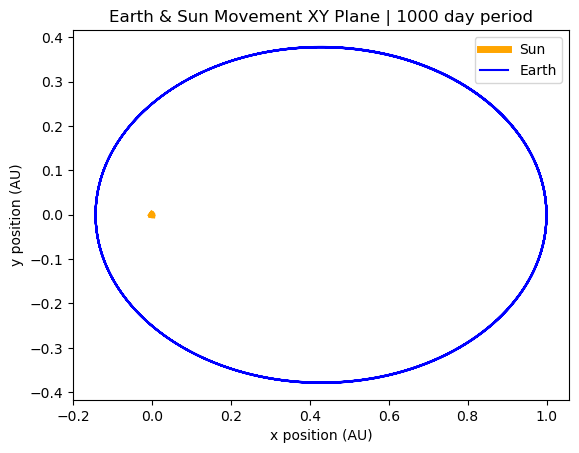

In [11]:
plt.plot(ptest2[:, 0, 0], ptest2[:, 0, 1], c='orange', label='Sun', lw=5)
plt.plot(ptest2[:, 1, 0], ptest2[:, 1, 1] , c='blue', label='Earth')
# plt.axis('square')
plt.xlabel('x position (AU)')
plt.ylabel('y position (AU)')
plt.title('Earth & Sun Movement XY Plane | 1000 day period')
plt.legend();

# the orbit becomes eliptical

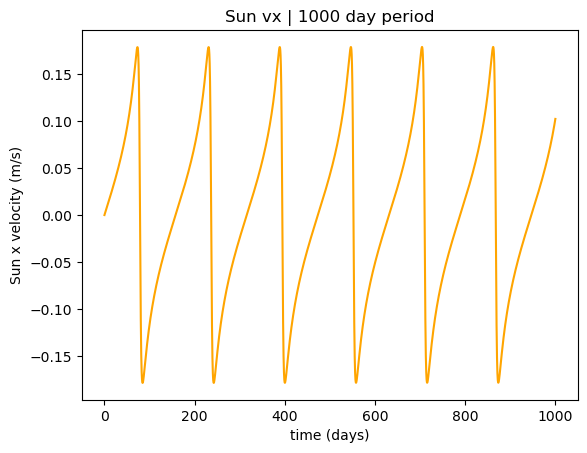

In [12]:
plt.plot(ttest2, vtest2[:, 0, 0], c='orange')
plt.xlabel('time (days)')
plt.ylabel('Sun x velocity (m/s)')
plt.title('Sun vx | 1000 day period');

# sharper movement, similar to Earth

#### section 4

##### 7

In [13]:
kep16 = np.genfromtxt('kepler16.txt')

In [14]:
print(kep16)
kep16.shape

[[ 1.3718e+30  7.6349e+09 -9.6587e+05  1.8447e+09 -1.0502e+03 -6.8224e+00
   1.3030e+04]
 [ 4.0287e+29 -2.5998e+10  3.2889e+06 -6.2813e+09  3.5760e+03  2.3231e+01
  -4.4368e+04]
 [ 6.3250e+26  3.7761e+10 -4.0923e+07  8.1934e+10 -3.6298e+04 -1.0812e+01
   1.7020e+04]]


(3, 7)

In [15]:
# variables without _ after to be fed into function

mkep16 = np.array(kep16[:, 0:1])  # kg
pkep16 = np.array(kep16[:, 1:4])  # m
vkep16 = np.array(kep16[:, 4:7])  # m/s

for i in [mkep16, pkep16, vkep16]:
    print(i)
    print(i.shape)
    print(' ')

# particles * mass
# particles * (x, y, z)
# particles * (vx, vy, vz)

[[1.3718e+30]
 [4.0287e+29]
 [6.3250e+26]]
(3, 1)
 
[[ 7.6349e+09 -9.6587e+05  1.8447e+09]
 [-2.5998e+10  3.2889e+06 -6.2813e+09]
 [ 3.7761e+10 -4.0923e+07  8.1934e+10]]
(3, 3)
 
[[-1.0502e+03 -6.8224e+00  1.3030e+04]
 [ 3.5760e+03  2.3231e+01 -4.4368e+04]
 [-3.6298e+04 -1.0812e+01  1.7020e+04]]
(3, 3)
 


##### 8

In [16]:
# scaling masses
mscaled = (np.log(mkep16) - 60)*10  # different kind of normalization, works nicely with such diversity in magnitudes
print(mscaled)

# m to AU
pkep16AU = pkep16 / mInAU

[[93.93676536]
 [81.6841144 ]
 [17.11722452]]


In [17]:
# vector components

dx = vkep16[:, 0]
dy = vkep16[:, 1]
dz = vkep16[:, 2]

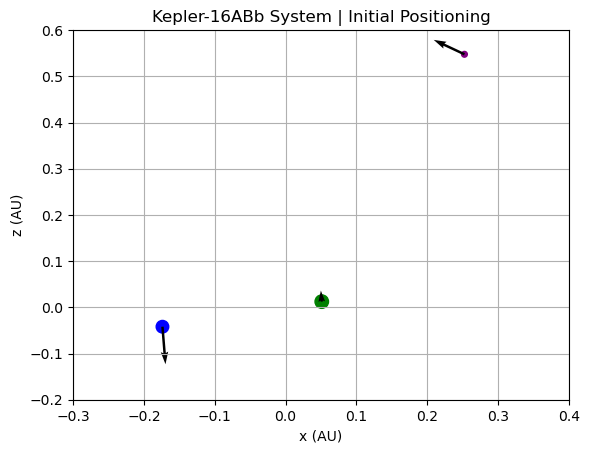

In [18]:
plt.grid('on')
plt.scatter(pkep16AU[:, 0],pkep16AU[:, 2] , s=mscaled, color=['green', 'blue', 'purple'])
plt.xlim(-.3, .4)
plt.ylim(-.2, .6)
plt.xlabel('x (AU)')
plt.ylabel('z (AU)')
plt.title('Kepler-16ABb System | Initial Positioning')
plt.quiver(pkep16AU[:, 0], pkep16AU[:, 2], dx, dz, width=.005);  # adjust arrow length/width according to the visual

##### 9

In [19]:
Time = 500 * secInDay  # 500 days in seconds
dTime = secInDay * 0.5  # 0.5 days in seconds

In [20]:
# variables w/ _ after are outputs of function

pkep16_, vkep16_, tkep16_ = calculateTrajectories(mkep16, pkep16, vkep16, Time, dTime)

In [21]:
# create an indexing/conversion function

def mToAUxyz(pArray):
    pArrayx = pArray[:, :, 0] / mInAU
    pArrayy = pArray[:, :, 1] / mInAU
    pArrayz = pArray[:, :, 2] / mInAU

    return pArrayx, pArrayy, pArrayz

In [22]:
for i in [pkep16_, vkep16_, tkep16_]:
    print(i.shape)
    print(' ')

# times * particles * (x, y, z)

pkep16x, pkep16y, pkep16z = mToAUxyz(pkep16_)

# for potentially adding quivers

vkep16x = pkep16_[:, :, 0]
vkep16y = pkep16_[:, :, 1]
vkep16z = pkep16_[:, :, 2]

print(pkep16x)

(1001, 3, 3)
 
(1001, 3, 3)
 
(1001,)
 
[[ 0.05103543 -0.17378342  0.2524131 ]
 [ 0.05059609 -0.17228739  0.2418956 ]
 [ 0.0498957  -0.16990234  0.23130966]
 ...
 [ 0.03512638 -0.13657961  0.59852113]
 [ 0.03275416 -0.12850903  0.59248343]
 [ 0.03023668 -0.11994357  0.58629585]]


##### 10

In [ ]:
# will attach animations separately

import matplotlib.animation as ani
FFMpegWriter = ani.writers['ffmpeg']
writer = FFMpegWriter(fps=100)

# create a blank figure object (e.g. blank piece of paper)
myImage = plt.figure()

# Some hocus pocus to make the axes look right.
#myImage.patch.set_alpha(1.0)

with writer.saving(myImage, "Kep16System.mp4", 150):
    # make each plot, and write it 
    for i in range(0,len(tkep16_), 2):
        # clear the axes (= the plot rectangle)
        plt.cla()

        # make the plot
        plt.scatter(pkep16x[i,:],pkep16z[i,:], s=mscaled/2, color=['green', 'blue', 'purple'])
        plt.title(f'Kepler-16ABb System: day {int(i)}')
        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.xlabel('x (AU)')
        plt.ylabel('z (AU)')
        
        # add the plot to the movie
        writer.grab_frame()

        if i % 500 == 0:
            print(f"saving movie frame {i}")        
        writer.grab_frame()


In [ ]:
from IPython.display import Video
Video("Kep16System.mp4", embed=True)

#### section 5

##### 11

In [24]:
# load in tinyCluster.txt using np.genfromtext and splice
# evolve over 500 days w/ steps of 0.5 days, adjust as needed
# check announcement hints again

tinyC = np.genfromtxt('tinyCluster.txt')

mtinyC = np.array(tinyC[:, 0:1])  # kg
ptinyC = np.array(tinyC[:, 1:4])  # m
vtinyC = np.array(tinyC[:, 4:7])  # m/s

for i in [mtinyC, ptinyC, vtinyC]:
    print(i.shape)
    print(' ')

(20, 1)
 
(20, 3)
 
(20, 3)
 


In [25]:
# time variables, evolving 2000 days every 6 hours

Time2 = 2000 * secInDay  # 2000 days in seconds
dTime2 = secInDay/4

In [26]:
ptinyC_, vtinyC_, ttinyC_ = calculateTrajectories(mtinyC, ptinyC, vtinyC, Time2, dTime2)

In [27]:
ptinyCx, ptinyCy, ptinyCz = mToAUxyz(ptinyC_)

print(len(ttinyC_))
mTCscaled = (np.log(mtinyC) - 60)*10
print(mTCscaled)

8001
[[20.59737079]
 [27.62626995]
 [46.82643529]
 [50.48265364]
 [35.13236562]
 [47.99669931]
 [49.46253745]
 [45.05043386]
 [50.52137097]
 [43.83857354]
 [50.83668758]
 [46.01391284]
 [47.96565347]
 [35.96273662]
 [51.12603579]
 [36.25361372]
 [44.16869894]
 [37.72814855]
 [48.34870619]
 [50.47815496]]


In [ ]:
fig = plt.figure(figsize=(4,3))
ax = plt.axes(projection='3d')
writer = FFMpegWriter(fps=80)

# write plots to frames of a movie
with writer.saving(fig, "TinyClusterSystem.mp4", 200):
    for i in range(0,len(ttinyC_), 10):
        plt.cla()
        #ax.view_init(0, 45)

        ax.scatter(ptinyCx[i,:],ptinyCy[i,:],ptinyCz[i,:], depthshade=True, s=mTCscaled)
        # ax.set_xlim(-10,10); ax.set_ylim(-10,10); ax.set_zlim(-10,10)
        ax.set_xlim(-2,2); ax.set_ylim(-2,2); ax.set_zlim(-2,2) 
        ax.set_xlabel('x (AU)'); ax.set_ylabel('y (AU)'); ax.set_zlabel('z (AU)')
        ax.set_title(f'Tiny Cluster System: day {int(i/4)}')
        
        if i % 2000 == 0:
            print(f"saving movie frame {i}")        
        writer.grab_frame()

##### 12

In [29]:
# use same base code as in 10
# evolve over time in all coordinates
# experiment with 3D glasses idea?

In [ ]:
from IPython.display import Video
Video("TinyClusterSystem.mp4", embed=True)

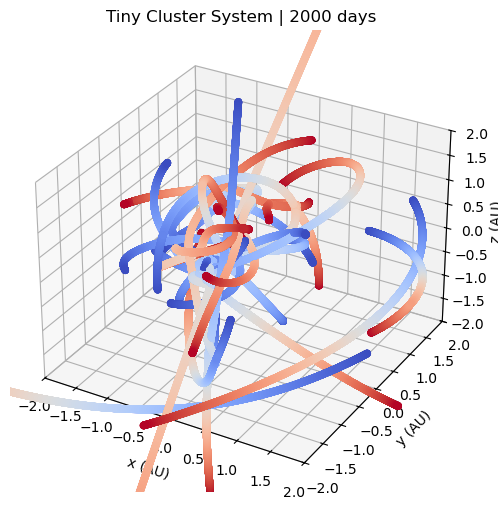

In [31]:
# experimenting w/ idea of color representing time parameter

fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')

ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (AU)', labelpad=1);
# ax.view_init(25, 40)

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_zlim(-2, 2)

# ax.plot(xline, yline, zline, 'gray')

ax.set_title('Tiny Cluster System | 2000 days')
timeColor = np.arange(0, 8001*20)

# Data for three-dimensional scattered points
ax.scatter(ptinyCx, ptinyCy, ptinyCz, c=timeColor, cmap='coolwarm');